# Phase 1 — EDA + Data Preparation

**Runs locally. No Azure. No compute cost.**  
Output: `data/processed/train_clean.csv`

Do not move to Phase 2 until the gate checklist at the bottom passes.

In [2]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

## Section 1 — Load

In [3]:
# ── LOAD ──────────────────────────────────────────────────────────────────────
DATA_PATH = 'C:\\Users\\Castl\\Documents\\Portfolio\\DS-Project-Blueprint\\data\\raw\\smart_manufacturing_data.csv'  #You can change this path for future datasets

df = pd.read_csv(DATA_PATH)
print(f'✓ Loaded {df.shape[0]:,} rows × {df.shape[1]} cols')

✓ Loaded 100,000 rows × 13 cols


In [4]:
# ── SHAPE + TYPES ─────────────────────────────────────────────────────────────
print('--- dtypes ---')
print(df.dtypes)
print()
print('--- head ---')
df.head()

--- dtypes ---
timestamp                    object
machine_id                    int64
temperature                 float64
vibration                   float64
humidity                    float64
pressure                    float64
energy_consumption          float64
machine_status                int64
anomaly_flag                  int64
predicted_remaining_life      int64
failure_type                 object
downtime_risk               float64
maintenance_required          int64
dtype: object

--- head ---


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [5]:
# ── BASIC STATS ───────────────────────────────────────────────────────────────
df.describe()

,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,downtime_risk,maintenance_required
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,75.015625,50.012270,54.995401,3.000405,2.747064,1.002050,0.089160,234.269160,0.089155,0.196970
std,14.389439,10.031884,14.985444,14.437960,1.152399,1.297865,0.446193,0.284976,150.063062,0.284961,0.397711
min,1.000000,35.550000,-17.090000,30.000000,1.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,13.000000,68.267500,39.970000,42.520000,2.000000,1.630000,1.000000,0.000000,97.000000,0.000000,0.000000
50%,25.000000,75.060000,49.960000,54.980000,3.010000,2.740000,1.000000,0.000000,230.000000,0.000000,0.000000
75%,38.000000,81.750000,60.100000,67.500000,4.000000,3.870000,1.000000,0.000000,365.000000,0.000000,0.000000
max,50.000000,121.940000,113.800000,80.000000,5.000000,5.000000,2.000000,1.000000,499.000000,1.000000,1.000000


In [6]:
# ── NULL CHECK ────────────────────────────────────────────────────────────────
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else '✓ No nulls found')

✓ No nulls found


## Section 2 — Target Variable

In [7]:
# ── TARGET DISTRIBUTION ───────────────────────────────────────────────────────
TARGET = 'maintenance_required'   # ← change this for other variables

print('Value counts:')
print(df[TARGET].value_counts())
print()
print('Class balance (%):')
print(df[TARGET].value_counts(normalize=True).mul(100).round(1))

Value counts:
maintenance_required
0    80303
1    19697
Name: count, dtype: int64

Class balance (%):
maintenance_required
0    80.3
1    19.7
Name: proportion, dtype: float64


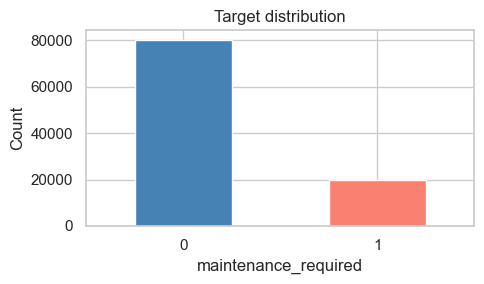

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
df[TARGET].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Target distribution')
ax.set_xlabel(TARGET)
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 3 — Distributions

In [9]:
# ── COLUMN ROLE DECLARATION ───────────────────────────────────────────────────
# Edit this block. You are the data scientist — you assign the roles,
# not the dtype detector.
#
# NUMERIC_COLS  : true continuous measurements (sensors, costs, ratios)
# CATEGORICAL_COLS : identifiers, labels, status codes — stored as int or str
# DROP_COLS     : leaky, redundant, or meaningless for modeling

NUMERIC_COLS = [
    'temperature',
    'vibration',
    'humidity',
    'pressure',
    'energy_consumption',
]

CATEGORICAL_COLS = [
    'machine_id',       # identifier, not a measurement
    'machine_status',   # operational state: 0=idle, 1=running, 2=failure
]

DROP_COLS = [
    'downtime_risk',
    'anomaly_flag',
    'failure_type',
    'predicted_remaining_life',
    'timestamp',        # raw timestamp — engineer time features later if needed
]

TARGET = 'maintenance_required'

# ── APPLY ROLES ───────────────────────────────────────────────────────────────
df.drop(columns=DROP_COLS, inplace=True)

print(f'✓ Numeric    ({len(NUMERIC_COLS)}): {NUMERIC_COLS}')
print(f'✓ Categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}')
print(f'✓ Target: {TARGET}')
print(f'✓ Dropped: {DROP_COLS}')
print(f'✓ Shape after drop: {df.shape}')

✓ Numeric    (5): ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']
✓ Categorical (2): ['machine_id', 'machine_status']
✓ Target: maintenance_required
✓ Dropped: ['downtime_risk', 'anomaly_flag', 'failure_type', 'predicted_remaining_life', 'timestamp']
✓ Shape after drop: (100000, 8)


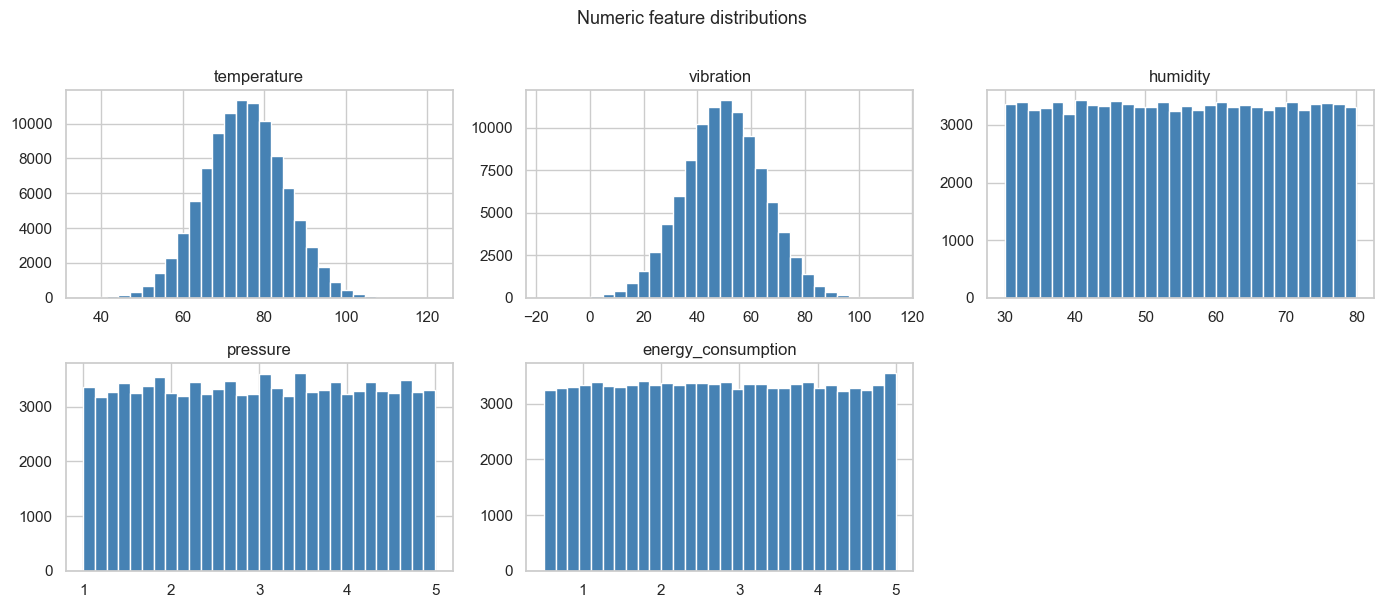

In [10]:
# ── NUMERIC DISTRIBUTIONS ────────────────────────────────────────────────────
n    = len(NUMERIC_COLS)
cols = 3
rows = (n + cols - 1) // cols # ceiling division to get enough rows for all numeric cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3)) # adjust height based on number of rows
axes = axes.flatten() # flatten in case of multiple rows

for i, col in enumerate(NUMERIC_COLS):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric feature distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# ── CATEGORICAL DISTRIBUTIONS ─────────────────────────────────────────────────
if CATEGORICAL_COLS:
    for col in CATEGORICAL_COLS:
        print(f'{col} — {df[col].nunique()} unique values')
        print(df[col].value_counts().head(10))
        print()
else:
    print('✓ No categorical columns declared')

machine_id — 50 unique values
machine_id
23    2092
36    2085
45    2080
30    2074
17    2061
26    2059
48    2058
38    2058
44    2054
21    2052
Name: count, dtype: int64

machine_status — 3 unique values
machine_status
1    80091
2    10057
0     9852
Name: count, dtype: int64



## Section 3.1 — Bivariate analysis

How does each feature behave differently for machines that need maintenance vs. those that do not?
This is the core question of a predictive maintenance problem.

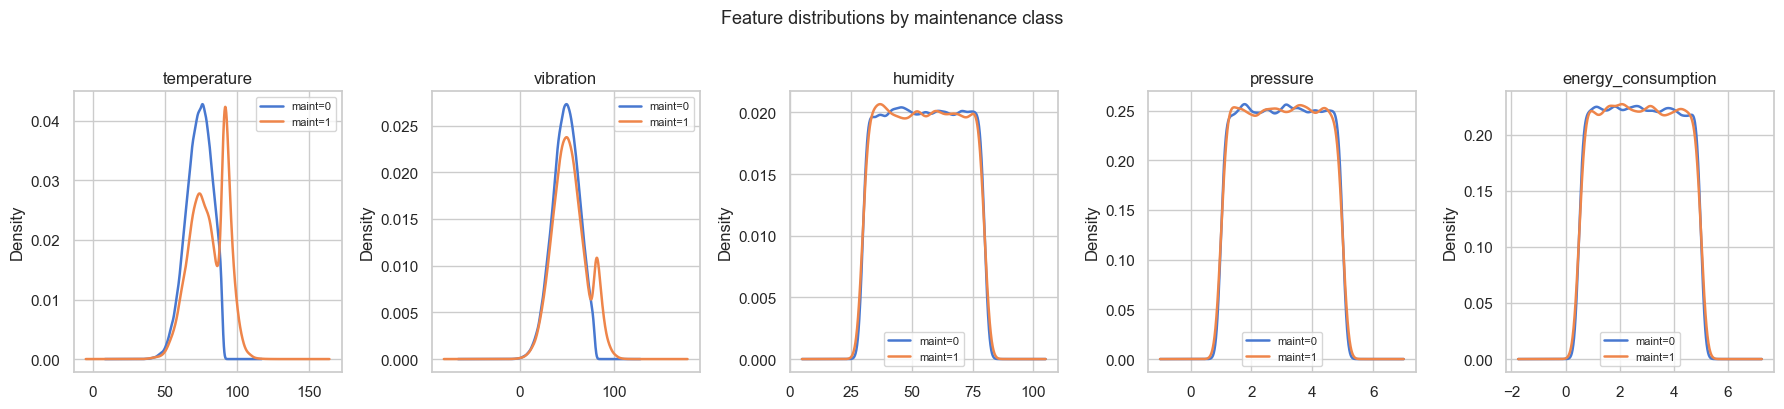

In [12]:
# ── CLASS-CONDITIONAL DISTRIBUTIONS ──────────────────────────────────────────
# For each sensor feature, plot the distribution split by target class.
# A feature with well-separated distributions has strong predictive signal.

TARGET = 'maintenance_required'
SENSOR_COLS = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']

fig, axes = plt.subplots(1, len(SENSOR_COLS), figsize=(18, 4))

for ax, col in zip(axes, SENSOR_COLS):
    for label, grp in df.groupby(TARGET)[col]:
        grp.plot.kde(ax=ax, label=f'maint={label}', linewidth=1.8)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Feature distributions by maintenance class', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# ── POINT-BISERIAL CORRELATION — feature signal strength ─────────────────────
# Measures linear association between each numeric feature and the binary target.
# |r| > 0.15 is a reasonable minimum threshold for inclusion.
# A low value here does not mean the feature is useless — trees capture
# non-linear relationships that this test misses.

from scipy import stats

print(f'{"Feature":<25} {"r":>8} {"p-value":>12} {"Signal?":>10}')
print('-' * 60)

for col in SENSOR_COLS:
    r, p = stats.pointbiserialr(df[TARGET], df[col].fillna(df[col].median()))
    flag = 'yes' if abs(r) > 0.10 else 'weak'
    print(f'{col:<25} {r:>8.4f} {p:>12.4e} {flag:>10}')

Feature                          r      p-value    Signal?
------------------------------------------------------------
temperature                 0.2830   0.0000e+00        yes
vibration                   0.1131  8.6356e-282        yes
humidity                   -0.0038   2.2770e-01       weak
pressure                   -0.0019   5.3848e-01       weak
energy_consumption          0.0014   6.6156e-01       weak


it measures how different the average feature value is between machines that need maintenance and machines that do not, normalized by variability.

## Section 4 — Outlier Detection

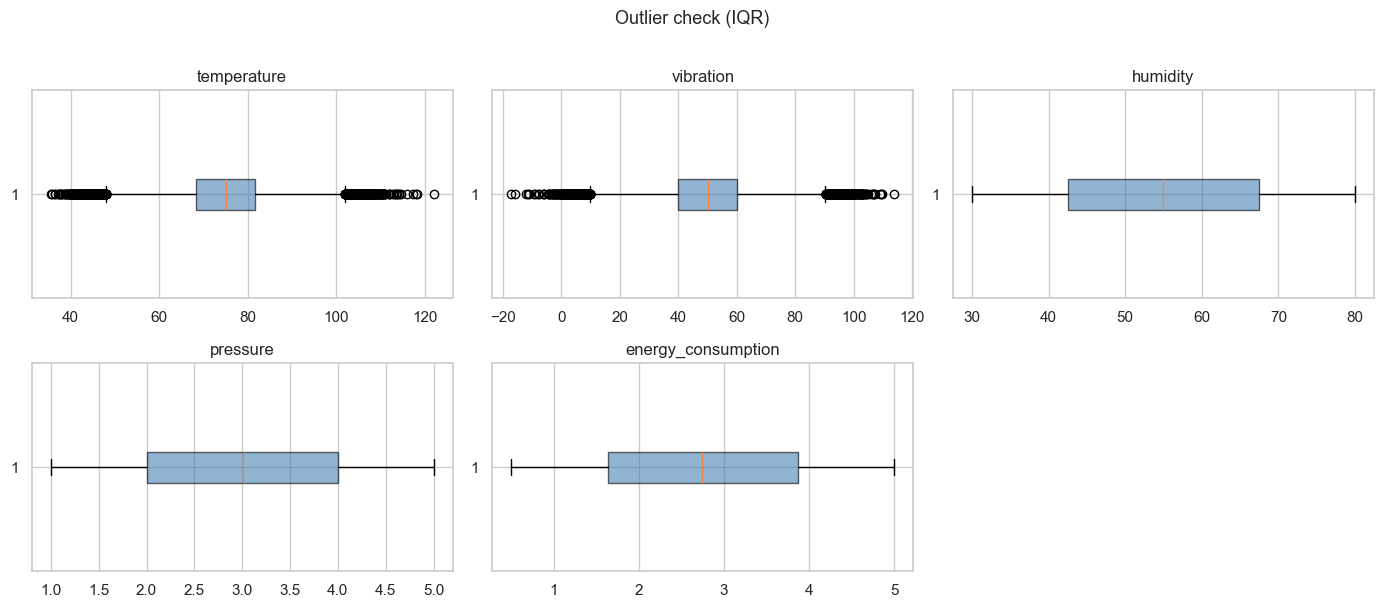

In [14]:
# ── BOXPLOTS ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier check (IQR)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# ── IQR OUTLIER SUMMARY ───────────────────────────────────────────────────────
print(f'{"Column":<30} {"Lower fence":>12} {"Upper fence":>12} {"Outliers":>10}')
print('-' * 68)

for col in NUMERIC_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:<30} {lower:>12.2f} {upper:>12.2f} {n_out:>10}')

Column                          Lower fence  Upper fence   Outliers
--------------------------------------------------------------------
temperature                           48.04       101.97        752
vibration                              9.77        90.30        719
humidity                               5.05       104.97          0
pressure                              -1.00         7.00          0
energy_consumption                    -1.73         7.23          0


## Section 4.1 — Domain-constrained vibration fix

Vibration cannot be negative (it is a magnitude). Negative values are sensor or encoding errors.
This is treated before the generic IQR outlier step.

In [16]:
# ── VIBRATION: DOMAIN FIX ────────────────────────────────────────────────────
# Physical constraint: vibration >= 0. Negative values violate sensor physics.
# Decision: clip to 0 rather than delete the row, because other columns
# in the same row remain valid.

n_neg = (df['vibration'] < 0).sum()
print(f'Negative vibration values found: {n_neg}')

df['vibration'] = df['vibration'].clip(lower=0)

print(f'✓ Vibration clipped to [0, {df["vibration"].max():.2f}]')
print(f'  New min: {df["vibration"].min():.4f}  |  mean: {df["vibration"].mean():.4f}')

Negative vibration values found: 37
✓ Vibration clipped to [0, 113.80]
  New min: 0.0000  |  mean: 50.0140


In [17]:
# ── OUTLIER TREATMENT ─────────────────────────────────────────────────────────
# Option A — cap at fences (winsorize). Uncomment and fill columns to treat.
# Option B — remove rows. Uncomment and fill.
# Option C — leave as-is (tree models handle outliers natively).
#
# Document your decision in README_TEMPLATE.md > Known data issues.

# --- Option A: cap ---
# for col in ['col1', 'col2']:
#     Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# --- Option B: remove ---
# for col in ['col1']:
#     Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

print(f'✓ Rows after outlier treatment: {len(df):,}')

✓ Rows after outlier treatment: 100,000


## Section 5 — Imputation

## Section 5.1 — Skewness summary

Skewness determines the right imputation strategy and whether log-transforms will help.
This runs before imputation and before feature engineering.

In [ ]:
# ── SKEWNESS SUMMARY ─────────────────────────────────────────────────────────
# |skew| < 0.5  → approximately normal → mean imputation is fine
# |skew| > 1.0  → right-skewed         → use median; consider log1p transform

print(f'{"Column":<25} {"Skewness":>10} {"Verdict":>20}')
print('-' * 58)

for col in df.select_dtypes(include='number').columns:
    sk = df[col].skew()
    verdict = 'log1p candidate' if abs(sk) > 1 else ('near-normal' if abs(sk) < 0.5 else 'moderate')
    print(f'{col:<25} {sk:>10.3f} {verdict:>20}')

In [ ]:
# ── IMPUTATION ────────────────────────────────────────────────────────────────
# Rule: median for skewed numerics, mean for normal numerics, mode for categoricals.
# Verify skew with df[col].skew() — |skew| > 1 → use median.
#
# Document strategy in README_TEMPLATE.md > Known data issues.

# --- Numeric: median ---
# for col in ['col1', 'col2']:
#     df[col].fillna(df[col].median(), inplace=True)

# --- Numeric: mean ---
# for col in ['col3']:
#     df[col].fillna(df[col].mean(), inplace=True)

# --- Categorical: mode ---
# for col in ['cat_col']:
#     df[col].fillna(df[col].mode()[0], inplace=True)

# --- Categorical: sentinel ---
# for col in ['cat_col']:
#     df[col].fillna('Unknown', inplace=True)

remaining_nulls = df.isnull().sum().sum()
print(f'✓ Nulls remaining: {remaining_nulls}')

## Section 6 — Feature Engineering

In [ ]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
# Only create features that will be available at inference time.
# Document each new column and why it was created.

# --- Log transform (right-skewed columns) ---
# df['col1_log'] = np.log1p(df['col1'])

# --- Ratio / interaction features ---
# df['ratio_col1_col2'] = df['col1'] / (df['col2'] + 1e-6)

# --- Label encoding ---
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df['cat_col_enc'] = le.fit_transform(df['cat_col'])
# df.drop(columns=['cat_col'], inplace=True)

# --- One-hot encoding (low cardinality) ---
# df = pd.get_dummies(df, columns=['cat_col'], drop_first=True)

print(f'✓ Shape after feature engineering: {df.shape}')

## Section 6.1 — Sensor interaction features

Physical intuition: machines fail when multiple sensors are simultaneously stressed.
Capturing joint extremes often outperforms individual sensor features alone.

In [ ]:
# ── INTERACTION FEATURES ─────────────────────────────────────────────────────
# These combinations have physical interpretations, not arbitrary math.
# temp_vib_product: simultaneous thermal and mechanical stress
# pressure_energy_ratio: efficiency proxy (high energy per unit pressure = strain)
# temp_z: how many standard deviations above average is this machine running?

# df['temp_vib_product'] = df['temperature'] * df['vibration']
# df['pressure_energy_ratio'] = df['energy_consumption'] / (df['pressure'] + 1e-6)
# df['temp_z'] = (df['temperature'] - df['temperature'].mean()) / df['temperature'].std()

# print('✓ Interaction features added:')
# print('  temp_vib_product — joint thermal + mechanical stress')
# print('  pressure_energy_ratio — energy efficiency proxy')
# print('  temp_z — temperature z-score')
# print(f'✓ Shape after engineering: {df.shape}')

## Section 6.2 — Per-machine aggregation features

A single reading is a snapshot. The trend over time is more predictive.
These features summarise each machine's recent history.

In [ ]:
# ── PER-MACHINE AGGREGATION ───────────────────────────────────────────────────
# Compute mean and standard deviation of each sensor per machine_id.
# The std (volatility) is often more predictive than the mean for fault detection:
# a machine running hot and unstable is more at risk than one running hot but steady.

agg_cols = ['temperature', 'vibration', 'pressure', 'energy_consumption']

machine_agg = (
    df.groupby('machine_id')[agg_cols]
    .agg(['mean', 'std'])
)
machine_agg.columns = ['_'.join(c) + '_by_machine' for c in machine_agg.columns]
machine_agg = machine_agg.reset_index()

df = df.merge(machine_agg, on='machine_id', how='left')

print(f'✓ Added {len(machine_agg.columns)-1} per-machine aggregation features')
print(f'✓ Shape after aggregation: {df.shape}')
print(machine_agg.head(3))

In [ ]:
# ── CORRELATION HEATMAP ───────────────────────────────────────────────────────
# Run after engineering to catch multicollinearity before locking the feature list.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

## Section 7 — Lock Features + Split + Save

In [18]:
# ── FEATURE LIST ──────────────────────────────────────────────────────────────
# Finalize here. Copy this block into README_TEMPLATE.md and src/train.py.
# Do not change it after Phase 2 starts.

FEATURES = [
    'temperature',
    'vibration',
    'humidity',
    'pressure',
    'energy_consumption'
]   

TARGET = 'maintenance_required'   

X = df[FEATURES].values
y = df[TARGET].values

print(f'✓ X shape: {X.shape}')
print(f'✓ y shape: {y.shape}')
print(f'✓ Features: {FEATURES}')

✓ X shape: (100000, 5)
✓ y shape: (100000,)
✓ Features: ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']


In [19]:
# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')

Train: 70,000 rows  |  Test: 30,000 rows


In [20]:
# ── SAVE CLEAN DATA ───────────────────────────────────────────────────────────
# Reconstruct DataFrames from the split arrays so the CSV keeps column names.
train_df = pd.DataFrame(X_train, columns=FEATURES)
train_df[TARGET] = y_train

test_df = pd.DataFrame(X_test, columns=FEATURES)
test_df[TARGET] = y_test

train_df.to_csv('../data/processed/train_clean.csv', index=False)
test_df.to_csv('../data/processed/test_clean.csv', index=False)

print(f'✓ Saved {len(train_df):,} rows → data/processed/train_clean.csv')
print(f'✓ Saved {len(test_df):,} rows  → data/processed/test_clean.csv')

✓ Saved 70,000 rows → data/processed/train_clean.csv
✓ Saved 30,000 rows  → data/processed/test_clean.csv


---
## Phase 1 Gate — do not move to Phase 2 until all boxes are checked

Run the cell below. All assertions must pass.

In [21]:
# ── GATE CHECK ────────────────────────────────────────────────────────────────
import os

clean = pd.read_csv('../data/processed/train_clean.csv')
errors = []

if clean.isnull().sum().sum() > 0:
    errors.append(f'FAIL — nulls found: {clean.isnull().sum()[clean.isnull().sum() > 0].to_dict()}')

non_numeric = clean.select_dtypes(include='object').columns.tolist()
if non_numeric:
    errors.append(f'FAIL — non-numeric columns: {non_numeric}')

if TARGET not in clean.columns:
    errors.append(f'FAIL — target column "{TARGET}" not found')

missing_features = [f for f in FEATURES if f not in clean.columns]
if missing_features:
    errors.append(f'FAIL — missing features: {missing_features}')

if errors:
    for e in errors:
        print(e)
else:
    print('✓ Zero nulls')
    print('✓ All columns numeric')
    print(f'✓ Target column "{TARGET}" present')
    print(f'✓ All {len(FEATURES)} features present')
    print(f'✓ Train rows: {len(clean):,}')
    print('\nPhase 1 complete — ready for Phase 2.')

✓ Zero nulls
✓ All columns numeric
✓ Target column "maintenance_required" present
✓ All 5 features present
✓ Train rows: 70,000

Phase 1 complete — ready for Phase 2.
